In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta
# pip install statsmodels
import joblib
# pip install joblib


In [4]:
df = pd.read_csv('./data_sensores.csv')

df_copy = df.copy()

# Convertir FechaHora a formato datetime
df_copy['FechaHora'] = pd.to_datetime(df_copy['FechaHora'])
df_copy.set_index('FechaHora', inplace=True)

predicciones = {}
dias_a_predecir = 14

In [5]:
model_P = ARIMA(df_copy['Fosforo'], order=(90, 1, 1))
model_fit_P = model_P.fit()

C:\Users\Menth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Menth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Menth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

In [6]:
fechas_futuras = [df_copy.index[-1] + timedelta(days=i) for i in range(1, dias_a_predecir + 1)]
df_predicciones = pd.DataFrame({'FechaHora': fechas_futuras})

C:\Users\Menth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Menth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x00000188CADEAE40>.

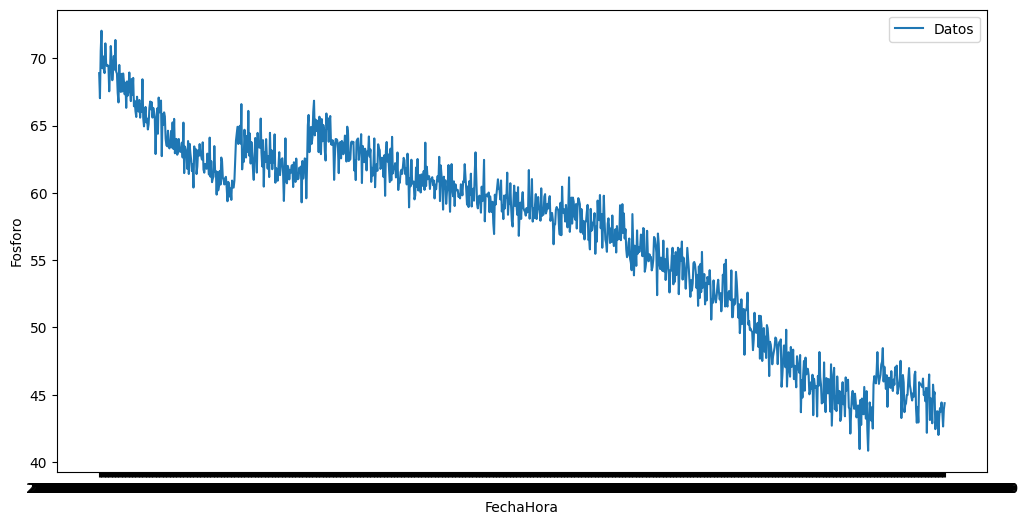

In [9]:
pred_P = model_fit_P.get_forecast(steps=dias_a_predecir)
predicciones['Fosforo'] = pred_P.predicted_mean
df_predicciones['Fosforo'] = predicciones['Fosforo'].values

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='FechaHora', y='Fosforo', label='Datos')
sns.lineplot(data=df_predicciones, x='FechaHora', y='Fosforo', label='Predicciones')
plt.title('Fosforo en el tiempo')
plt.show()

In [10]:
joblib.dump(model_fit_P, 'model_fit_P.joblib')

['model_fit_P.joblib']